In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from wordcloud import WordCloud

print("Packages installed and imported successfully!")

Packages installed and imported successfully!


In [3]:
import pandas as pd
import os

file_path = r"C:\Users\ajejx\Schule\BBB\2. Jahr\M259 ML\LB-M259-1000Woerter.txt"

news = pd.read_csv(
    file_path,
    sep='\t',              # <-- Tab als Trennzeichen!
    on_bad_lines='skip',   # Fehlerhafte Zeilen überspringen
    encoding='latin1'      # Windows-kompatibles Encoding
)

news.head(30)

,title,text,subject,date,label,the,to,of,a,and,...,proposal,currently,seven,photo,form,risk,mccain,stay,share,points
0,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,22072017.0,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,0
1,YOU WONT BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,19062017.0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,2112017.0,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
3,SCOUNDREL HILLARY SUPPORTER STARTS TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,17092016.0,0,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,0
4,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,26052017.0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
5,EU's Tusk appealed to Rajoy to avoid escalatio...,European Council President Donald Tusk appeale...,worldnews,2102017.0,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
6,Country Guitarist Who Survived Vegas Shooting ...,"Caleb Keeter, a lifelong proponent of the Seco...",News,2102017.0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
7,Clinton says 'there is no case here' in FBI em...,Democratic presidential candidate Hillary Clin...,politicsNews,31102016.0,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
8,ABC NEWS REPORTS: Las Vegas Massacre Suspects...,The investigation into the Las Vegas massacre ...,politics,25102017.0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
9,BONKERS BERNIE SANDERS: Prioritizing Jobs Over...,https://www.youtube.com/watch?v=GPqQIlWksbgVer...,politics,1042017.0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


# 2.1


Ich möchte vorhersagen, bei welchen Wörtern und Themen (subjects) Fake News am häufigsten sind. Ich möchte auch den Zeitraum mit einbeziehen (in welchem Zeitraum waren Fake News am meisten verbreitet). Mit diesem Wissen kann man auch Bezug zur echten Welt kriegen, z.B. hat es mehr Fake News wenn Wahlen, vor allem US-Wahlen, bevorstehen.

In [5]:
!pip install matplotlib wordcloud scikit-learn pandas numpy

     ---------------------------------------- 7.8/7.8 MB 10.4 MB/s eta 0:00:00
     -------------------------------------- 300.4/300.4 KB 9.4 MB/s eta 0:00:00
     --------------------------------------- 11.2/11.2 MB 11.9 MB/s eta 0:00:00
     ---------------------------------------- 55.8/55.8 KB ? eta 0:00:00
     ---------------------------------------- 2.2/2.2 MB 10.0 MB/s eta 0:00:00
     -------------------------------------- 211.8/211.8 KB 6.3 MB/s eta 0:00:00
     -------------------------------------- 111.1/111.1 KB 6.3 MB/s eta 0:00:00
     ---------------------------------------- 2.6/2.6 MB 11.1 MB/s eta 0:00:00
     ---------------------------------------- 46.2/46.2 MB 7.8 MB/s eta 0:00:00
     ------------------------------------- 301.8/301.8 KB 18.2 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Users\ajejx\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Daten erfolgreich mit latin1 Encoding geladen!
Anzahl der Einträge: 9999
Beispiel-Datensatz:
                                               title  \
0  Ex-CIA head says Trump remarks on Russia inter...   
1  YOU WONT BELIEVE HIS PUNISHMENT! HISPANIC STO...   

                                                text          subject  \
0  Former CIA director John Brennan on Friday cri...     politicsNews   
1  How did this man come to OWN this store? There...  Government News   

         date  label  the  to  of  a  and  ...  proposal  currently  seven  \
0  22072017.0      1    1   1   1  1    1  ...         0          0      0   
1  19062017.0      0    1   1   1  1    1  ...         0          0      0   

   photo  form  risk  mccain  stay  share  points  
0      0     1     0       0     0      0       0  
1      0     0     0       0     0      0       0  

[2 rows x 1005 columns]

Grundlegende Analyse

Label-Verteilung:
label
0    5181
1    4818
Name: count, dtype: int64

Anteil F

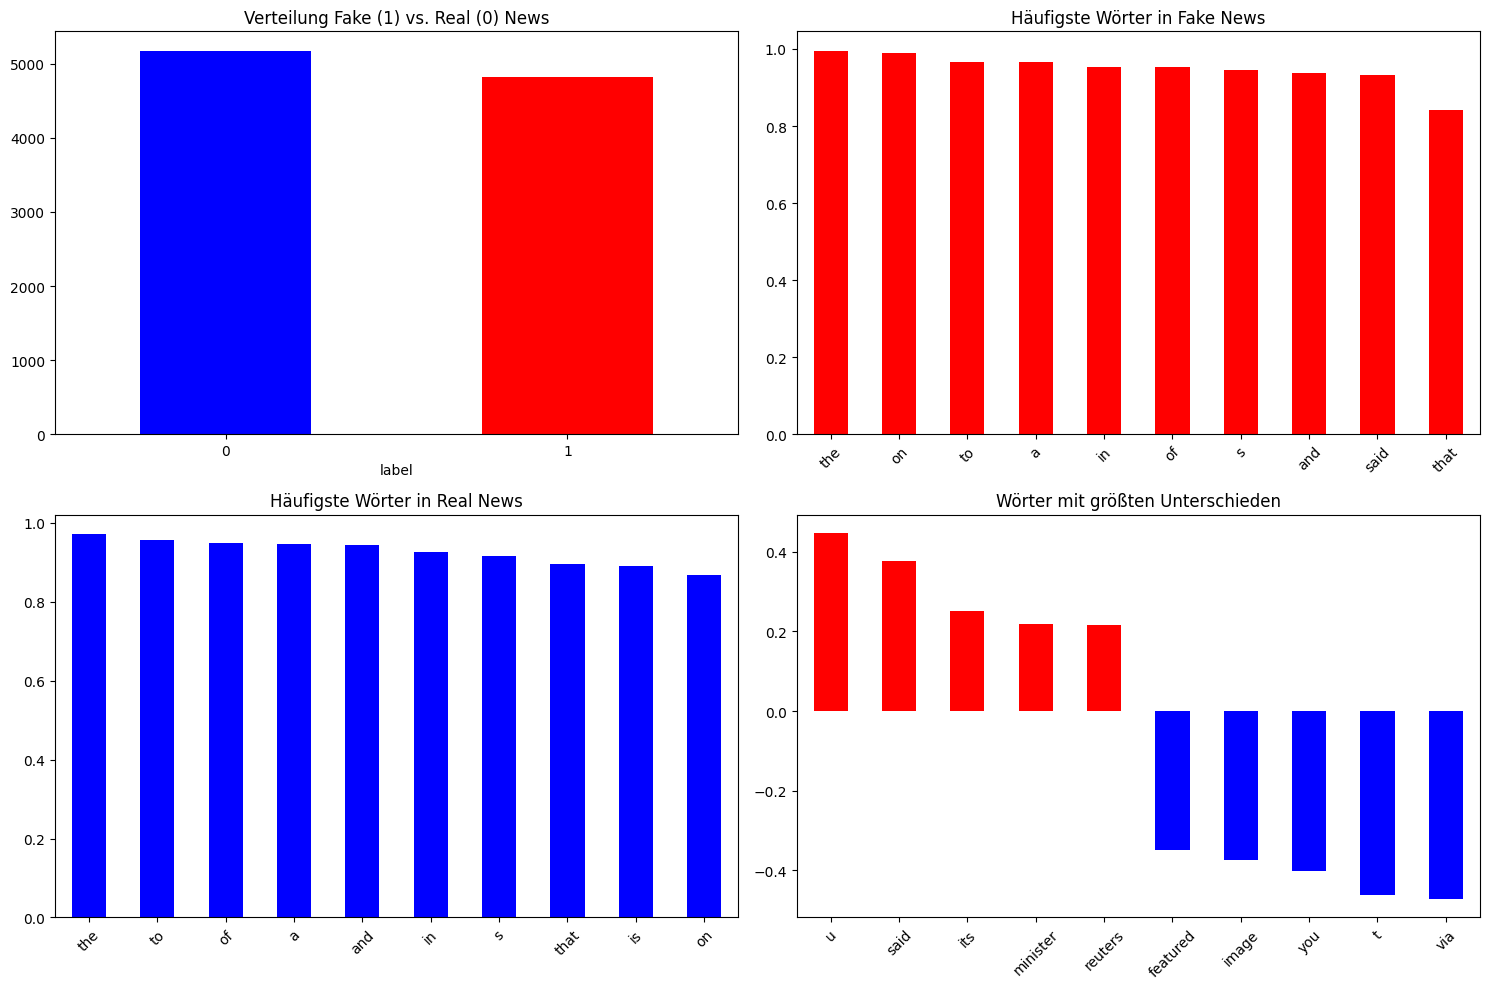


Zusätzliche Statistiken

Durchschnittliche Wortanzahl pro Artikel:
Fake News: 116.8
Real News: 128.4

Häufigste Subjects in Fake News:
subject
politicsNews    2541
worldnews       2277
Name: count, dtype: int64

Häufigste Subjects in Real News:
subject
News               2051
politics           1446
left-news          1007
Government News     347
US_News             171
Name: count, dtype: int64

Fehlende Werte pro Spalte:
title         0
text          0
subject       0
date          2
label         0
             ..
mccain        0
stay          0
share         0
points        0
word_count    0
Length: 1006, dtype: int64


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# 1. Daten mit latin1 Encoding laden
try:
    df = pd.read_csv('LB-m259-1000Woerter.txt', delimiter='\t', encoding='latin1')
    print("Daten erfolgreich mit latin1 Encoding geladen!")
    print(f"Anzahl der Einträge: {len(df)}")
    print("Beispiel-Datensatz:")
    print(df.head(2))
    
    # Bereinigung: Entferne Zeilen mit fehlenden Werten in wichtigen Spalten
    df = df.dropna(subset=['label', 'title'])
    
except Exception as e:
    print(f"Fehler beim Laden: {e}")
    raise

# 2. Grundlegende Analyse
print("\n" + "="*50)
print("Grundlegende Analyse")
print("="*50)

# Label-Verteilung
label_counts = df['label'].value_counts()
print(f"\nLabel-Verteilung:\n{label_counts}")

# Anteil Fake News
fake_ratio = label_counts[1]/label_counts.sum()
print(f"\nAnteil Fake News: {fake_ratio:.2%}")

# 3. Erweiterte Textanalyse
print("\n" + "="*50)
print("Wortfrequenz-Analyse")
print("="*50)

# Identifiziere Wortspalten (alle nach den ersten 5 Spalten)
word_cols = [col for col in df.columns[5:] if df[col].dtype in [np.int64, np.float64]]

if word_cols:
    # Trennung der Daten
    fake = df[df['label'] == 1]
    real = df[df['label'] == 0]
    
    # Top Wörter für Fake News
    top_fake_words = fake[word_cols].mean().sort_values(ascending=False).head(10)
    
    # Top Wörter für Real News
    top_real_words = real[word_cols].mean().sort_values(ascending=False).head(10)
    
    # Wörter mit größten Unterschieden
    word_diff = (fake[word_cols].mean() - real[word_cols].mean()).sort_values(ascending=False)
    top_diff_words = word_diff.head(10)
    bottom_diff_words = word_diff.tail(10)
    
    print("\nTop 10 Wörter in Fake News:")
    print(top_fake_words)
    
    print("\nTop 10 Wörter in Real News:")
    print(top_real_words)
    
    print("\nTop 10 Wörter häufiger in Fake News:")
    print(top_diff_words)
    
    print("\nTop 10 Wörter häufiger in Real News:")
    print(bottom_diff_words)
else:
    print("\nKeine Wortzähl-Spalten gefunden")

# 4. Visualisierungen
plt.figure(figsize=(15, 10))

# Label-Verteilung
plt.subplot(2, 2, 1)
df['label'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Verteilung Fake (1) vs. Real (0) News')
plt.xticks(rotation=0)

# Wortverteilung (falls Wortspalten vorhanden)
if word_cols:
    # Top Fake News Wörter
    plt.subplot(2, 2, 2)
    top_fake_words.plot(kind='bar', color='red')
    plt.title('Häufigste Wörter in Fake News')
    plt.xticks(rotation=45)
    
    # Top Real News Wörter
    plt.subplot(2, 2, 3)
    top_real_words.plot(kind='bar', color='blue')
    plt.title('Häufigste Wörter in Real News')
    plt.xticks(rotation=45)
    
    # Größte Unterschiede
    plt.subplot(2, 2, 4)
    pd.concat([top_diff_words.head(5), bottom_diff_words.tail(5)]).plot(kind='bar', 
                                                                       color=['red']*5 + ['blue']*5)
    plt.title('Wörter mit größten Unterschieden')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. Zusätzliche Statistiken
print("\n" + "="*50)
print("Zusätzliche Statistiken")
print("="*50)

# Durchschnittliche Wortanzahl pro Artikel
if word_cols:
    df['word_count'] = df[word_cols].sum(axis=1)
    print(f"\nDurchschnittliche Wortanzahl pro Artikel:")
    print(f"Fake News: {df[df['label']==1]['word_count'].mean():.1f}")
    print(f"Real News: {df[df['label']==0]['word_count'].mean():.1f}")
    
    # Subjects Analyse
    if 'subject' in df.columns:
        print("\nHäufigste Subjects in Fake News:")
        print(df[df['label']==1]['subject'].value_counts().head(5))
        
        print("\nHäufigste Subjects in Real News:")
        print(df[df['label']==0]['subject'].value_counts().head(5))

# Zeige mögliche fehlende Werte
print("\nFehlende Werte pro Spalte:")
print(df.isnull().sum())

# 2.3

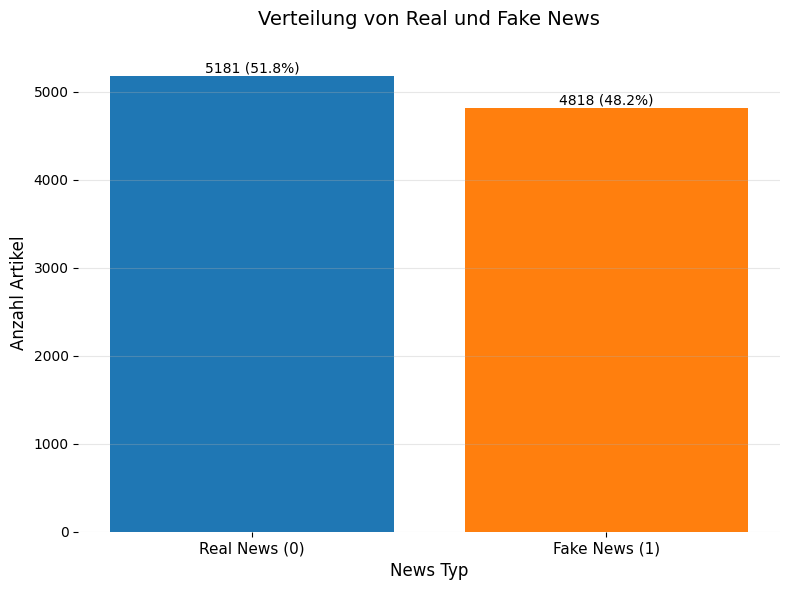

In [18]:
#Hier sind alle Artikel die Real sind (links) und Fake (rechts)
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Daten laden
try:
    df = pd.read_csv('LB-m259-1000Woerter.txt', delimiter='\t', encoding='latin1')
    
    # 2. Nur die Label-Verteilung plotten
    plt.figure(figsize=(8, 6))
    
    # Daten für die Grafik vorbereiten
    label_counts = df['label'].value_counts()
    colors = ['#1f77b4', '#ff7f0e']  # Blau für Real, Orange für Fake
    labels = ['Real News (0)', 'Fake News (1)']
    
    # Balkendiagramm erstellen
    bars = plt.bar(labels, label_counts, color=colors)
    
    # Werte über den Balken anzeigen
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height} ({height/len(df)*100:.1f}%)',
                ha='center', va='bottom')
    
    # Diagramm beschriften
    plt.title('Verteilung von Real und Fake News', fontsize=14, pad=20)
    plt.xlabel('News Typ', fontsize=12)
    plt.ylabel('Anzahl Artikel', fontsize=12)
    plt.xticks(fontsize=11)
    
    # Rahmen entfernen
    for spine in plt.gca().spines.values():
        spine.set_visible(False)
    
    # Gitterlinien hinzufügen
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Fehler beim Laden der Daten: {e}")

## 2.3 Verteilung von Real und Fake News 

Hier sehen Sie, wie viele von den 10'000 Artikel sich als Real News bewiesen haben, und wie viele sich als Fake News herausgestellt haben.
Der Anteil ist viel ausgeglichener, als ich es vor der Auswertung antizipiert habe (ich vermutete, es hätte mehr Fake News).

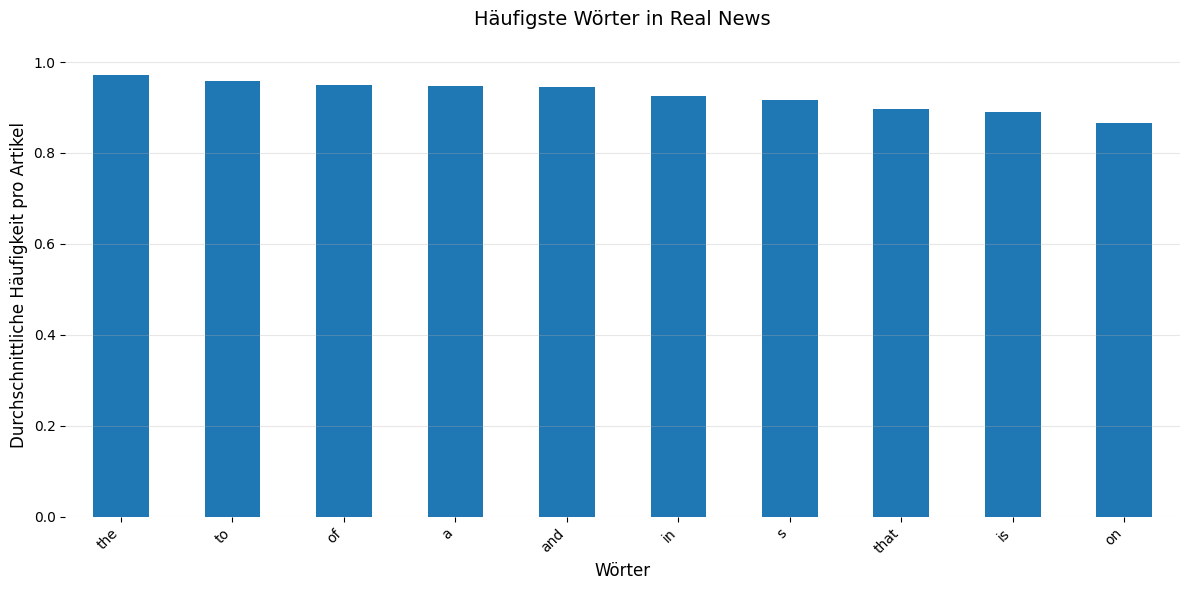

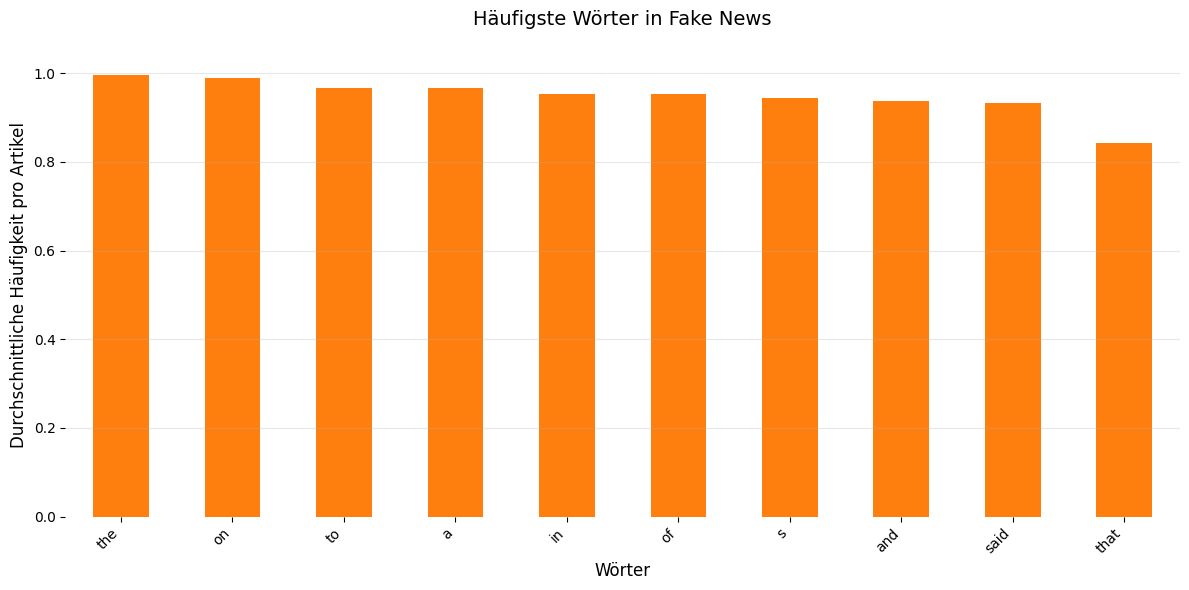

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# 1. Daten laden
try:
    df = pd.read_csv('LB-m259-1000Woerter.txt', delimiter='\t', encoding='latin1')
    
    # 2. Daten aufteilen
    fake_news = df[df['label'] == 1]
    real_news = df[df['label'] == 0]
    
    # 3. Wortspalten identifizieren (alle numerischen Spalten nach den ersten 5 Spalten)
    word_cols = [col for col in df.columns[5:] if df[col].dtype in [np.int64, np.float64]]
    
    if word_cols:
        # 4. Häufigste Wörter in Real News
        plt.figure(figsize=(12, 6))
        top_real_words = real_news[word_cols].mean().sort_values(ascending=False).head(10)
        top_real_words.plot(kind='bar', color='#1f77b4')
        plt.title('Häufigste Wörter in Real News', fontsize=14, pad=20)
        plt.xlabel('Wörter', fontsize=12)
        plt.ylabel('Durchschnittliche Häufigkeit pro Artikel', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        for spine in plt.gca().spines.values():
            spine.set_visible(False)
        plt.tight_layout()
        
        # 5. Häufigste Wörter in Fake News
        plt.figure(figsize=(12, 6))
        top_fake_words = fake_news[word_cols].mean().sort_values(ascending=False).head(10)
        top_fake_words.plot(kind='bar', color='#ff7f0e')
        plt.title('Häufigste Wörter in Fake News', fontsize=14, pad=20)
        plt.xlabel('Wörter', fontsize=12)
        plt.ylabel('Durchschnittliche Häufigkeit pro Artikel', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        for spine in plt.gca().spines.values():
            spine.set_visible(False)
        plt.tight_layout()
        
        plt.show()
        
    else:
        print("Keine Wortzähl-Spalten gefunden")

except Exception as e:
    print(f"Fehler beim Laden der Daten: {e}")

### 2.3 Die häufigsten Wörter
Wie Sie sehen (wieder zu meiner Überraschung), sind die Wörter nicht ein mal wirklich verschieden, es sind "Basic" englische Wörter. Ich hätte erwartet, dass, vor allem bei Fake News, mehr mit dem "Finger gezeigt" wird (Schuld auf Andere schieben) mit Wörtern wie "Trump", "China", "Russia", "North Korea" und so weiter. Aber ich lag falsch.

# 2.4
Bei mir macht Skalierung keinen Sinn, weil der Hauptteil meines Datensatzes (die häufigsten Wörter, Fake/Real News und "subjects" bzw. Themen) kann man nicht weiter aufteilen. Bei den Fake/Real News und den häufigsten Wörtern sind die Werte binär d.h. entweder 0 oder 1, und man kann es nicht weiter aufteilen. Bei der Spalte "title" und "text" finde ich, kann man auch nichts mehr machen, weil dort der Text stark variiert und man ihn nur sehr schwer kategorisieren kann.